In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [52]:
df = pd.read_csv(r"C:\Users\joysn\Desktop\EcommerceCustomers.csv")

In [53]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [57]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
df.rename(columns={"avg._session_length":"avg_session_length"}, inplace=True)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   email                 500 non-null    object 
 1   address               500 non-null    object 
 2   avatar                500 non-null    object 
 3   avg_session_length    500 non-null    float64
 4   time_on_app           500 non-null    float64
 5   time_on_website       500 non-null    float64
 6   length_of_membership  500 non-null    float64
 7   yearly_amount_spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [59]:
df.describe()

,avg_session_length,time_on_app,time_on_website,length_of_membership,yearly_amount_spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


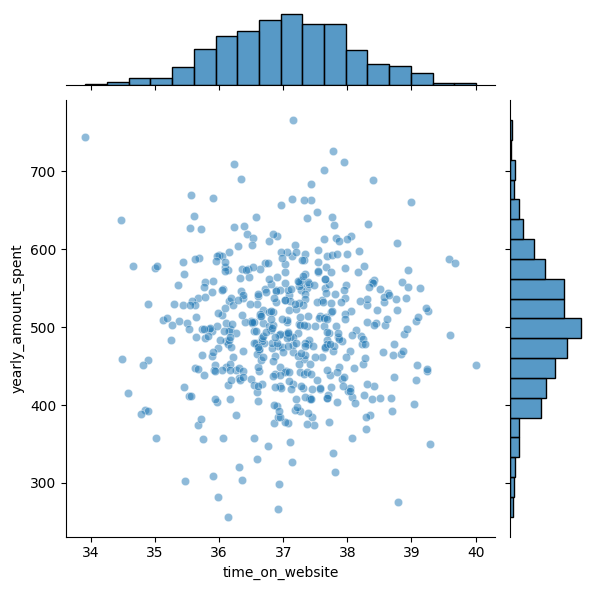

In [60]:
# EDA
sns.jointplot(x="time_on_website", y="yearly_amount_spent", data=df, alpha=0.5)

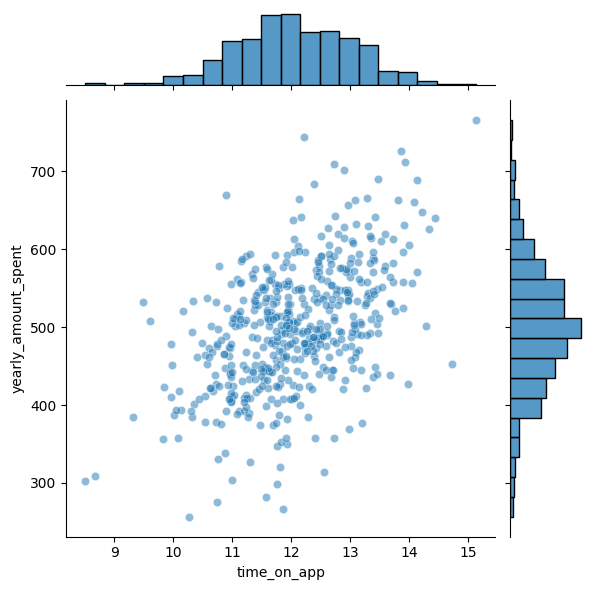

In [61]:
sns.jointplot(x="time_on_app", y="yearly_amount_spent", data=df, alpha=0.5)

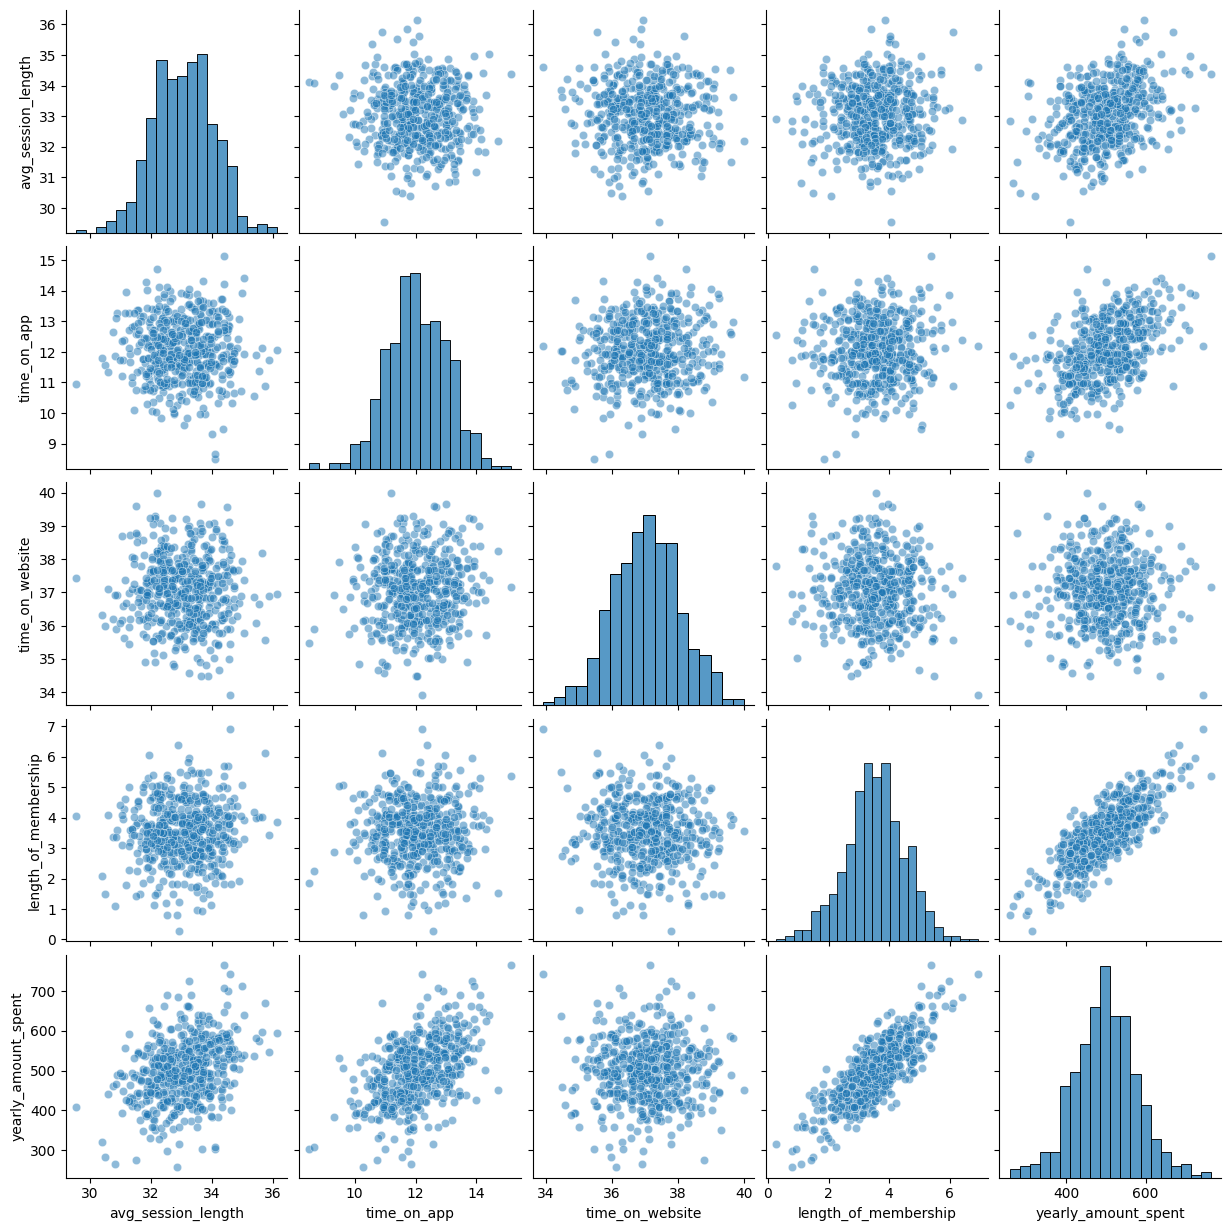

In [62]:
sns.pairplot(data=df, kind='scatter', plot_kws={'alpha':0.5})

<Axes: ylabel='length_of_membership'>

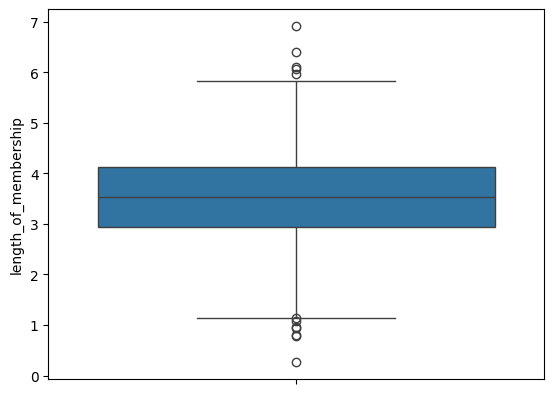

In [63]:
sns.boxplot(df['length_of_membership'])

<Axes: ylabel='avg_session_length'>

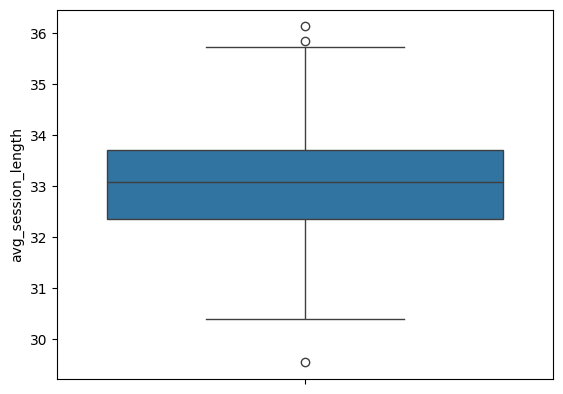

In [64]:
sns.boxplot(df['avg_session_length'])

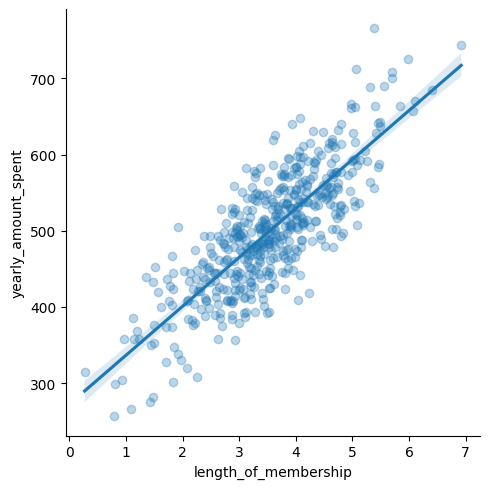

In [65]:
sns.lmplot(x='length_of_membership', y='yearly_amount_spent', data=df, scatter_kws={'alpha':0.3})

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X = df[['avg_session_length', 'time_on_app', 'time_on_website', 'length_of_membership']]
y = df['yearly_amount_spent']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [71]:
y_test

361    401.033135
73     534.777188
374    418.602742
155    503.978379
104    410.069611
          ...    
266    554.003093
23     519.340989
222    502.409785
261    514.009818
426    530.766719
Name: yearly_amount_spent, Length: 150, dtype: float64

In [72]:
# training the model
from sklearn.linear_model import LinearRegression

In [73]:
lm = LinearRegression()

In [74]:
lm.fit(X_train, y_train)

LinearRegression()

In [75]:
lm.coef_

array([25.72425621, 38.59713548,  0.45914788, 61.67473243])

In [76]:
cdf = pd.DataFrame(X.columns, lm.coef_,  columns=['Coef'])
print(cdf)

                           Coef
25.724256    avg_session_length
38.597135           time_on_app
0.459148        time_on_website
61.674732  length_of_membership


In [77]:
# predictions
predictions = lm.predict(X_test)

In [78]:
predictions

array([403.66993069, 542.57756289, 427.06591658, 502.02460425,
       410.12143559, 569.93442508, 531.93431341, 506.29650969,
       408.71870658, 473.97737105, 441.46912726, 425.33703059,
       425.1297229 , 527.61676714, 431.45684016, 424.0769184 ,
       575.76543296, 484.89856554, 458.35936863, 481.96502182,
       502.32441491, 513.63783554, 507.58877002, 646.57464283,
       450.24372141, 496.27043415, 556.40457807, 554.95630839,
       399.64237199, 325.84623136, 532.89783259, 478.12238702,
       501.05701845, 305.97335848, 505.77244448, 483.79591969,
       518.8331528 , 438.18241857, 456.71094234, 471.04609461,
       494.44008972, 445.31155755, 508.78802753, 501.04594193,
       488.83499673, 535.38079541, 595.20129802, 514.04714872,
       280.76758312, 433.10112367, 421.70823427, 481.23640152,
       584.71372272, 608.7748096 , 563.98513427, 494.72804869,
       394.52133407, 456.4197529 , 573.08767515, 499.6984241 ,
       512.83277025, 392.12434043, 480.05057697, 481.54

Text(0.5, 1.0, 'Evaluation of LM')

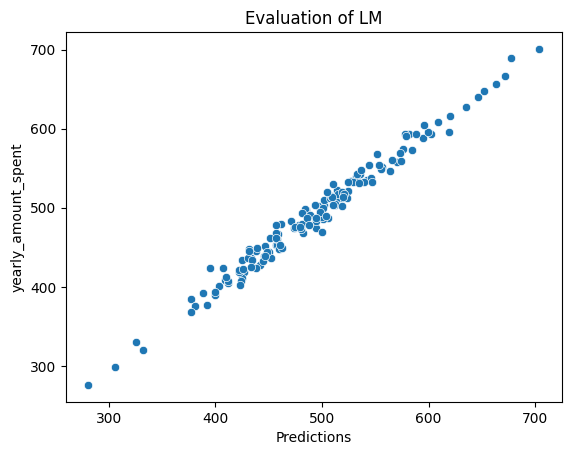

In [79]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predictions")
plt.title("Evaluation of LM")

In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [81]:
print("Mean Absolute Error: ", mean_absolute_error(y_test, predictions))
print("Mean Squared Error: ", mean_squared_error(y_test, predictions))
print("RMSE: ", math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error:  8.426091641432116
Mean Squared Error:  103.91554136503333
RMSE:  10.193897260863155


<Axes: xlabel='yearly_amount_spent', ylabel='Count'>

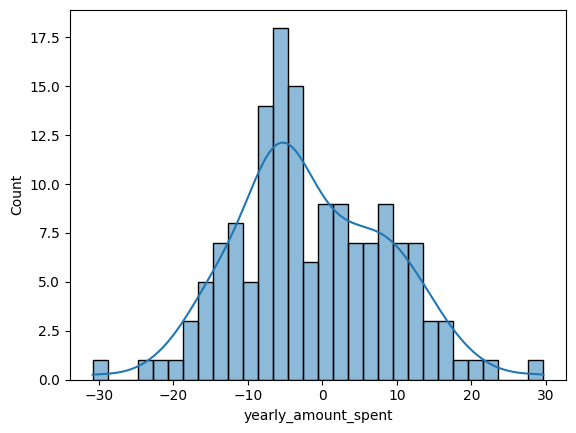

In [82]:
# residuals
residuals = y_test - predictions
sns.histplot(data=residuals, bins=30, kde=True)

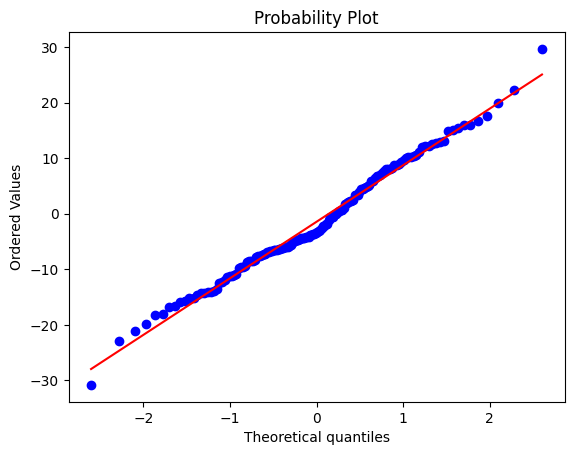

In [83]:
import pylab
import scipy.stats as stats
stats.probplot(residuals, dist=stats.norm, plot=pylab)
pylab.show()

In [84]:
from sklearn.metrics import r2_score

In [85]:
r2 = r2_score(y_test, predictions)

In [86]:
r2

0.9808757641125855

In [87]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

In [88]:
adjusted_r2

0.9803481989846567

In [89]:
import pickle

In [90]:
with open("model.pkl", "wb") as f:
    pickle.dump(lm, f)